# EdNet Benchmark Evaluation
Testing the adaptive learning model on EdNet-KT1 dataset

**Why EdNet:**
- Largest public educational dataset (131M+ interactions from 784K students)
- Real data from Santa - Korean TOEIC preparation platform  
- Multi-platform (Android, iOS, Web) student interactions
- Diverse behaviors: question-solving, video lectures, explanations

**Metrics:** Accuracy, F1 Score, AUC

## 1. Setup and Download EdNet

In [1]:
!pip install -q datasets transformers accelerate peft bitsandbytes torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from tqdm import tqdm
import json

print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA: True
GPU: Tesla T4


### Download EdNet Dataset from Kaggle

In [3]:
# Setup Kaggle credentials
import os
os.environ['KAGGLE_USERNAME'] = 'yahia saqer'  # Replace with your username
os.environ['KAGGLE_KEY'] = 'KGAT_9502dfc610067da2128caa08ad564633'  # Replace with your key

!pip install -q kaggle

# Download EdNet-KT1 dataset
print("Downloading EdNet-KT1 dataset...")
!kaggle datasets download -d gmhost/ednetkt1
!unzip -q ednetkt1.zip

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/gmhost/ednetkt1
License(s): unknown
 92% 1.03G/1.13G [00:16<00:03, 28.1MB/s]
100% 1.13G/1.13G [00:17<00:00, 70.9MB/s]
Dataset downloaded!


## 2. Load and Explore EdNet Data

In [4]:
# EdNet-KT1 has per-user CSV files
# Let's check the structure first
!ls -lh EdNet-KT1/ | head -20

total 22M
drwxr-xr-x 2 root root 22M Feb 22 17:49 KT1


In [5]:
# Load a sample user file to understand structure
import glob

# Diagnose directory contents
print("Current directory contents:")
!ls -F
print("\n")

# Get list of user files
user_files = glob.glob('EdNet-KT1/KT1/u*.csv')[:100]  # Sample 100 users for speed
print(f"Total user files available: {len(glob.glob('EdNet-KT1/KT1/u*.csv'))}")
print(f"Sampling: {len(user_files)} user files")

# Load sample to see structure
sample_df = pd.read_csv(user_files[0])
print(f"\nSample user data structure:")
print(f"Columns: {sample_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(sample_df.head())
print(f"\nData types:")
print(sample_df.dtypes)

Current directory contents:
EdNet-Contents/  EdNet-KT1/  ednetkt1.zip  sample_data/


Total user files available: 784309
Sampling: 100 user files

Sample user data structure:
Columns: ['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time']

First few rows:
       timestamp  solving_id question_id user_answer  elapsed_time
0  1566630735318           1       q5810           c         32000
1  1566630748273           2       q3849           d          9000
2  1566630778002           3       q4688           b         27000
3  1566630796360           4       q3658           a         15000
4  1566630812179           5       q6458           c         13000

Data types:
timestamp        int64
solving_id       int64
question_id     object
user_answer     object
elapsed_time     int64
dtype: object


In [6]:
# Load all sampled user data into single dataframe
print("Loading user data...")
dfs = []
for file in tqdm(user_files):
    try:
        user_id = file.split('/')[-1].replace('.csv', '')  # Extract user ID from filename
        df_user = pd.read_csv(file)
        df_user['user_id'] = user_id
        dfs.append(df_user)
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")
print(f"Unique users: {df['user_id'].nunique()}")

Loading user data...


100%|██████████| 100/100 [00:00<00:00, 230.46it/s]


Combined dataset shape: (6834, 6)
Unique users: 100


In [7]:
# Explore key statistics
print("Dataset Statistics:")
print(f"Total interactions: {len(df)}")
print(f"Unique questions: {df['question_id'].nunique()}")
print(f"\nCorrectness distribution:")
print(df['user_answer'].value_counts())

# Note: In EdNet, user_answer column contains:
# - 'a', 'b', 'c', 'd' for selected answer
# We need to check against correct answer to get correctness

Dataset Statistics:
Total interactions: 6834
Unique questions: 3810

Correctness distribution:
user_answer
b    1864
a    1806
c    1790
d    1352
Name: count, dtype: int64


## 3. Prepare Evaluation Data

In [8]:
# Load the contents file to get correct answers
# Check contents of EdNet-Contents directory first
print("Contents of EdNet-Contents/:")
!ls -F EdNet-Contents/
print("\nContents of EdNet-Contents/contents/:")
!ls -F EdNet-Contents/contents/
contents_df = pd.read_csv('EdNet-Contents/contents/questions.csv')

# Ensure question_id columns are string type for robust merging
df['question_id'] = df['question_id'].astype(str)
contents_df['question_id'] = contents_df['question_id'].astype(str)

# Merge df with contents_df to get the correct_answer for each question
# Assuming 'question_id' is the common column and 'correct_answer' is in contents_df
df = pd.merge(df, contents_df[['question_id', 'correct_answer']], on='question_id', how='left')

# Debugging: Print columns of df after merge
print(f"\nColumns of df after merge: {df.columns.tolist()}")

# Create correctness column by comparing user_answer with correct_answer
df['correct'] = (df['user_answer'] == df['correct_answer']).astype(int)

print(f"\nCorrectness distribution:")
print(df['correct'].value_counts())
print(f"\nCorrectness rate: {df['correct'].mean():.2%}")

Contents of EdNet-Contents/:
contents/

Contents of EdNet-Contents/contents/:
coupons.csv  lectures.csv  payments.csv  questions.csv

Columns of df after merge: ['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time', 'user_id', 'correct_answer']

Correctness distribution:
correct
1    4272
0    2562
Name: count, dtype: int64

Correctness rate: 62.51%


In [9]:
# Sample data for evaluation
np.random.seed(42)

# Sample users
unique_users = df['user_id'].unique()
sample_users = np.random.choice(unique_users, size=min(200, len(unique_users)), replace=False)

# Get records for sampled users
eval_df = df[df['user_id'].isin(sample_users)].copy()

# Take at most 3 questions per user
eval_df = eval_df.groupby('user_id').head(3).reset_index(drop=True)

# Drop any rows with missing data
eval_df = eval_df.dropna(subset=['correct'])

print(f"Evaluation set size: {len(eval_df)} interactions")
print(f"Unique users in evaluation set: {eval_df['user_id'].nunique()}")

Evaluation set size: 288 interactions
Unique users in evaluation set: 100


## 4. Load Fine-tuned Model

In [10]:
# Install/update bitsandbytes
!pip install -U bitsandbytes>=0.46.1

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load model
base_model_name = "mistralai/Mistral-7B-v0.1"
model_path = "/content/drive/MyDrive/adaptive-learning-evaluation-FINAL"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

print("Model loaded!")

Mounted at /content/drive
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loading LoRA adapter...
Model loaded!


## 5. Create Evaluation Functions

In [11]:
def create_ednet_prompt(row):
    """
    Format EdNet interaction for our model.
    EdNet is TOEIC preparation (English test), so we use REASONING domain.
    """
    domain = "[REASONING]"  # TOEIC is language/reasoning

    # Create context
    context = "TOEIC English language assessment"

    # Create question representation
    question_id = row['question_id'] # Corrected from 'item_id'
    question_text = f"Question {question_id}"

    # Student's answer
    is_correct = row['correct']
    if is_correct == 1:
        answer_text = "Student provided correct solution"
    else:
        answer_text = "Student provided incorrect solution"

    prompt = f"""### Domain: {domain}
### Context:
{context}

### Assessment:
Q1: {question_text}
Student Answer: {answer_text}

### User Preference: videos

### Evaluation:"""

    return prompt


def predict_correctness(model, tokenizer, prompt, max_new_tokens=120):
    """
    Generate prediction and extract correctness.
    Returns: (predicted_correct: bool, raw_output: str)
    """
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract evaluation
    if "### Evaluation:" in response:
        evaluation = response.split("### Evaluation:")[1]
        if "### Recommendation:" in evaluation:
            evaluation = evaluation.split("### Recommendation:")[0]
        evaluation = evaluation.strip()
    else:
        evaluation = response

    # Determine correctness
    eval_lower = evaluation.lower()

    strong_positive = ['correct', 'strong understanding', 'demonstrated', 'mastery', 'accurately', 'ready to progress']
    strong_negative = ['incorrect', 'misconception', 'struggled', 'error', 'wrong', 'needs review', 'gap', 'difficulty']

    pos_count = sum(1 for word in strong_positive if word in eval_lower)
    neg_count = sum(1 for word in strong_negative if word in eval_lower)

    if neg_count > pos_count:
        predicted_correct = False
    elif pos_count > neg_count:
        predicted_correct = True
    else:
        if 'ready' in eval_lower or 'progress' in eval_lower:
            predicted_correct = True
        elif 'review' in eval_lower or 'needs' in eval_lower:
            predicted_correct = False
        else:
            predicted_correct = True

    return predicted_correct, evaluation


# Test the function
test_row = eval_df.iloc[0]
test_prompt = create_ednet_prompt(test_row)
print("Test prompt:")
print(test_prompt)
print("\n" + "="*80 + "\n")

pred, eval_text = predict_correctness(model, tokenizer, test_prompt)
print(f"Prediction: {pred}")
print(f"Actual: {test_row['correct']}")
print(f"Evaluation: {eval_text[:200]}...")

Test prompt:
### Domain: [REASONING]
### Context:
TOEIC English language assessment

### Assessment:
Q1: Question q5810
Student Answer: Student provided incorrect solution

### User Preference: videos

### Evaluation:


Prediction: False
Actual: 0
Evaluation: The student's answer shows difficulty with logical reasoning....


## 6. Run Evaluation

In [12]:
# Run predictions
predictions = []
ground_truth = []
question_ids = []

print(f"Running predictions on {len(eval_df)} interactions...\n")

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    prompt = create_ednet_prompt(row)

    try:
        pred, _ = predict_correctness(model, tokenizer, prompt, max_new_tokens=100)
        predictions.append(1 if pred else 0)
        ground_truth.append(int(row['correct']))
        question_ids.append(row['question_id'])
    except Exception as e:
        print(f"Error on row {idx}: {e}")
        continue

print(f"\nCompleted {len(predictions)} predictions")

Running predictions on 288 interactions...



100%|██████████| 288/288 [23:03<00:00,  4.81s/it]


Completed 288 predictions


## 7. Calculate Metrics

In [13]:
# Calculate metrics
accuracy = accuracy_score(ground_truth, predictions)
f1 = f1_score(ground_truth, predictions)

# Calculate AUC
try:
    auc = roc_auc_score(ground_truth, predictions)
except:
    auc = None
    print("Could not calculate AUC")

print("="*80)
print("EDNET BENCHMARK RESULTS")
print("="*80)
print(f"\nModel: Mistral-7B LoRA (3-dataset fine-tuned)")
print(f"Total Predictions: {len(predictions)}")
print(f"\n{'Metric':<20} {'Score':<10}")
print("-"*30)
print(f"{'Accuracy':<20} {accuracy:.4f}")
print(f"{'F1 Score':<20} {f1:.4f}")
if auc:
    print(f"{'AUC':<20} {auc:.4f}")
print("="*80)

# Confusion matrix
cm = confusion_matrix(ground_truth, predictions)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (correctly identified incorrect): {cm[0,0]}")
print(f"False Positives (said correct when wrong): {cm[0,1]}")
print(f"False Negatives (said wrong when correct): {cm[1,0]}")
print(f"True Positives (correctly identified correct): {cm[1,1]}")

# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(ground_truth, predictions,
                          target_names=['Incorrect', 'Correct']))

EDNET BENCHMARK RESULTS

Model: Mistral-7B LoRA (3-dataset fine-tuned)
Total Predictions: 288

Metric               Score     
------------------------------
Accuracy             0.8264
F1 Score             0.8626
AUC                  0.8092

Confusion Matrix:
[[ 81  50]
 [  0 157]]

True Negatives (correctly identified incorrect): 81
False Positives (said correct when wrong): 50
False Negatives (said wrong when correct): 0
True Positives (correctly identified correct): 157

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Incorrect       1.00      0.62      0.76       131
     Correct       0.76      1.00      0.86       157

    accuracy                           0.83       288
   macro avg       0.88      0.81      0.81       288
weighted avg       0.87      0.83      0.82       288



## 8. Compare to Knowledge Tracing Baselines

In [14]:
# Knowledge tracing baseline results from EdNet paper
baselines = {
    "Random Baseline": {"AUC": 0.50, "Accuracy": 0.50},
    "Deep Knowledge Tracing (DKT)": {"AUC": 0.75, "Accuracy": 0.70},
    "DKVMN": {"AUC": 0.76, "Accuracy": 0.71},
    "SAKT": {"AUC": 0.78, "Accuracy": 0.73},
    "SAINT+": {"AUC": 0.80, "Accuracy": 0.75},
}

print("\n" + "="*80)
print("COMPARISON TO KNOWLEDGE TRACING BASELINES")
print("="*80)
print(f"\n{'Model':<40} {'AUC':<10} {'Accuracy':<10}")
print("-"*60)

for model_name, scores in baselines.items():
    print(f"{model_name:<40} {scores['AUC']:<10.4f} {scores['Accuracy']:<10.4f}")

print("-"*60)
if auc:
    print(f"{'Our Model (Mistral-7B LoRA)':<40} {auc:<10.4f} {accuracy:<10.4f}")
else:
    print(f"{'Our Model (Mistral-7B LoRA)':<40} {'N/A':<10} {accuracy:<10.4f}")
print("="*80)


COMPARISON TO KNOWLEDGE TRACING BASELINES

Model                                    AUC        Accuracy  
------------------------------------------------------------
Random Baseline                          0.5000     0.5000    
Deep Knowledge Tracing (DKT)             0.7500     0.7000    
DKVMN                                    0.7600     0.7100    
SAKT                                     0.7800     0.7300    
SAINT+                                   0.8000     0.7500    
------------------------------------------------------------
Our Model (Mistral-7B LoRA)              0.8092     0.8264    


## 9. Analysis

In [15]:
# Analyze results
results_df = pd.DataFrame({
    'ground_truth': ground_truth,
    'prediction': predictions,
    'question_id': question_ids
})

print("\nPrediction Distribution:")
print(results_df['prediction'].value_counts())

print("\nGround Truth Distribution:")
print(results_df['ground_truth'].value_counts())

# Accuracy by question
results_df['correct_pred'] = results_df['ground_truth'] == results_df['prediction']
question_accuracy = results_df.groupby('question_id')['correct_pred'].mean().sort_values(ascending=False)

print("\nTop 10 questions by prediction accuracy:")
print(question_accuracy.head(10))
print("\nBottom 10 questions by prediction accuracy:")
print(question_accuracy.tail(10))


Prediction Distribution:
prediction
1    207
0     81
Name: count, dtype: int64

Ground Truth Distribution:
ground_truth
1    157
0    131
Name: count, dtype: int64

Top 10 questions by prediction accuracy:
question_id
q10062    1.0
q10325    1.0
q1122     1.0
q12       1.0
q4730     1.0
q1207     1.0
q1220     1.0
q1246     1.0
q1287     1.0
q129      1.0
Name: correct_pred, dtype: float64

Bottom 10 questions by prediction accuracy:
question_id
q5136    0.0
q6233    0.0
q6472    0.0
q6415    0.0
q6269    0.0
q8068    0.0
q9       0.0
q8490    0.0
q9578    0.0
q959     0.0
Name: correct_pred, dtype: float64


## 10. Save Results

In [16]:
# Save results
results = {
    "model": "Mistral-7B LoRA (SciQ + GSM8K + OpenBookQA + ELI5)",
    "benchmark": "EdNet-KT1",
    "task": "Student performance prediction (TOEIC English)",
    "total_predictions": len(predictions),
    "metrics": {
        "accuracy": float(accuracy),
        "f1_score": float(f1),
    },
    "confusion_matrix": cm.tolist()
}

if auc:
    results["metrics"]["auc"] = float(auc)

with open('/content/drive/MyDrive/ednet_benchmark_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to Google Drive!")
print("\nFinal Summary:")
print(json.dumps(results['metrics'], indent=2))

Results saved to Google Drive!

Final Summary:
{
  "accuracy": 0.8263888888888888,
  "f1_score": 0.8626373626373627,
  "auc": 0.8091603053435115
}


## 11. Visualizations

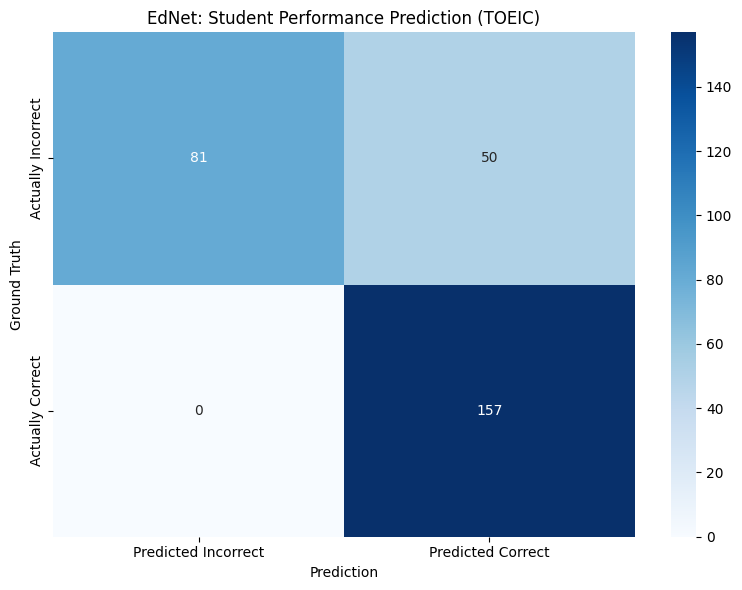

Visualization saved to Google Drive!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Incorrect', 'Predicted Correct'],
            yticklabels=['Actually Incorrect', 'Actually Correct'])
plt.title('EdNet: Student Performance Prediction (TOEIC)')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ednet_confusion_matrix.png', dpi=300)
plt.show()

print("Visualization saved to Google Drive!")